In [1]:
import pandas as pd, numpy as np
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

BASE = r"D:\Mortgage-Credit-Risk-Analytics\Data\processed"
PERF_PATH = BASE + r"\master_monthly_performance_clean.parquet"
OG_PATH   = BASE + r"\master_origination_clean.parquet"
PD_PATH   = "behavioural_pd_output.parquet"          # saved at the end of the PD notebook

pd_df = pd.read_parquet(PD_PATH)
og = pd.read_parquet(OG_PATH)
print("PD output loaded:", pd_df.shape)
print(pd_df.head())
print("\nPD summary:\n", pd_df["PD"].describe().round(4).to_string())

PD output loaded: (471654, 3)
    loan_seq_no  origination_year        PD
0  F00Q10000049              2000  0.048464
1  F00Q10000095              2000  0.299407
2  F00Q10000106              2000  0.052282
3  F00Q10000108              2000  0.053802
4  F00Q10000184              2000  0.072853

PD summary:
 count    471654.0000
mean          0.1156
std           0.1628
min           0.0016
25%           0.0228
50%           0.0609
75%           0.1402
max           0.9965


In [2]:
# load modelled LGD 
lgd_out = pd.read_parquet("lgd_model_output.parquet")
print("LGD model output loaded:", lgd_out.shape)
print(lgd_out[["indexed_ltv","LGD"]].describe().round(3).to_string())

LGD model output loaded: (471654, 3)
       indexed_ltv         LGD
count   471654.000  471654.000
mean        69.158       0.287
std         17.805       0.132
min         10.000       0.000
25%         59.000       0.194
50%         75.000       0.284
75%         80.000       0.374
max        250.000       1.000


In [3]:
book = pd_df.merge(og[["loan_seq_no", "og_upb", "og_ltv"]], on="loan_seq_no", how="left")
book = book.merge(lgd_out[["loan_seq_no", "LGD"]],
                  on = "loan_seq_no", how = "left")
book = book.rename(columns={"og_upb": "EAD"})
book["EAD"] = pd.to_numeric(book["EAD"], errors="coerce")
book["LGD"] = book["LGD"].fillna(book["LGD"].median())  # safety fill
print("book with EAD and modelled LGD:", book.shape)
print("missing EAD:", int(book["EAD"].isna().sum()))
print("missing LGD:=", int(book["LGD"].isna().sum()))
book = book.dropna(subset=["EAD", "LGD"])

book with EAD and modelled LGD: (471654, 6)
missing EAD: 0
missing LGD:= 0


#### EL = PD × LGD × EAD

Apply the segmented LGD (by each loan's LTV) and combine with the model PD and EAD.

In [4]:
book["EL"]  = book["PD"] * book["LGD"] * book["EAD"]

total_el, total_ead = book["EL"].sum(), book["EAD"].sum()
print("="*55)
print("PORTFOLIO EXPECTED LOSS")
print("="*55)
print(f"loans                 : {len(book):,}")
print(f"total exposure (EAD)  : ${total_ead:,.0f}")
print(f"total Expected Loss   : ${total_el:,.0f}")
print(f"EL as % of exposure   : {total_el/total_ead*100:.2f}%")
print(f"mean PD               : {book['PD'].mean():.3f}")
print(f"mean applied LGD      : {book['LGD'].mean():.3f}")

# sanity check: EL ~ meanPD * meanLGD * meanEAD * N
approx = book['PD'].mean()*book['LGD'].mean()*book['EAD'].mean()*len(book)
print(f"\nsanity check (approx EL): ${approx:,.0f}  (should be same order as total EL)")

PORTFOLIO EXPECTED LOSS
loans                 : 471,654
total exposure (EAD)  : $78,109,216,000
total Expected Loss   : $3,044,368,297
EL as % of exposure   : 3.90%
mean PD               : 0.116
mean applied LGD      : 0.287

sanity check (approx EL): $2,588,409,590  (should be same order as total EL)


In [5]:
# EL decomposition: what's driving the portfolio loss?
print("\n"+ " "*25 +"EL DECOMPOSITION ")

# contribution by driver
book["el_pct"] = book["EL"] / book["EAD"] * 100

# PD contribution: rank loans by PD, show EL concentration
book["pd_decile"] = pd.qcut(book["PD"], 10, labels=False, duplicates="drop") + 1
pd_conc = book.groupby("pd_decile").agg(
    loans=("loan_seq_no","count"),
    EL=("EL","sum"),
    mean_PD=("PD","mean"),
    mean_LGD=("LGD","mean")).reset_index()
pd_conc["EL_share_%"] = (pd_conc["EL"] / pd_conc["EL"].sum() * 100).round(1)
print("\nEL concentration by PD decile (decile 10 = highest PD):")
print(pd_conc.round(3).to_string(index=False))

# LGD contribution: rank by LTV band
book["ltv_band"] = pd.cut(pd.to_numeric(book["og_ltv"], errors="coerce"),
                           [0, 60, 70, 80, 90, 100, 150])
ltv_el = book.groupby("ltv_band", observed=True).agg(
    loans=("loan_seq_no","count"),
    EL=("EL","sum"),
    mean_LGD=("LGD","mean"),
    mean_PD=("PD","mean")).reset_index()
ltv_el["EL_share_%"] = (ltv_el["EL"] / ltv_el["EL"].sum() * 100).round(1)
print("\nEL by LTV band:")
print(ltv_el.round(3).to_string(index=False))

# top 10% of loans by EL — concentration risk
top10_el = book.nlargest(int(len(book)*0.1), "EL")["EL"].sum()
print(f"\ntop 10% of loans by EL account for "
      f"{top10_el/book['EL'].sum()*100:.1f}% of total portfolio EL")


                         EL DECOMPOSITION 

EL concentration by PD decile (decile 10 = highest PD):
 pd_decile  loans           EL  mean_PD  mean_LGD  EL_share_%
         1  47166 7.731243e+06    0.007     0.141         0.3
         2  47165 2.282371e+07    0.014     0.199         0.7
         3  47165 4.555527e+07    0.023     0.239         1.5
         4  47166 7.774228e+07    0.035     0.267         2.6
         5  47165 1.202108e+08    0.051     0.290         3.9
         6  47165 1.775312e+08    0.073     0.310         5.8
         7  47166 2.543631e+08    0.101     0.329         8.4
         8  47165 3.599636e+08    0.141     0.347        11.8
         9  47165 5.304585e+08    0.208     0.364        17.4
        10  47166 1.447988e+09    0.503     0.380        47.6

EL by LTV band:
  ltv_band  loans           EL  mean_LGD  mean_PD  EL_share_%
   (0, 60] 129785 1.904854e+08     0.151    0.050         6.3
  (60, 70]  73722 4.114349e+08     0.295    0.100        13.5
  (70, 80] 194

#### EL by vintage: the through-the-cycle view

Because we scored the whole book, we can show EL by origination year: benign vs. crisis vintages.
This is also where you report **per-vintage PD AUC** (if you re-score with labels) to justify that the
model travels across vintages rather than being trusted blindly.

 origination_year  loans   exposure           EL  mean_PD  mean_LGD  EL_%
             2000  36472 4275857000 1.599618e+08    0.105     0.347  3.74
             2001  43109 5749924000 1.936969e+08    0.099     0.329  3.37
             2002  35346 4601615000 1.529755e+08    0.099     0.308  3.32
             2003  44658 6315116000 1.182133e+08    0.062     0.261  1.87
             2004  44431 6746495000 1.798116e+08    0.086     0.272  2.67
             2005  45553 7688761000 3.274713e+08    0.126     0.278  4.26
             2006  44772 7927737000 5.402097e+08    0.188     0.302  6.81
             2007  44157 7941242000 5.576637e+08    0.203     0.305  7.02
             2008  40395 7897731000 4.134268e+08    0.164     0.286  5.23
             2009  46687 9763231000 1.957417e+08    0.070     0.242  2.00
             2010  46074 9201507000 2.051959e+08    0.073     0.245  2.23


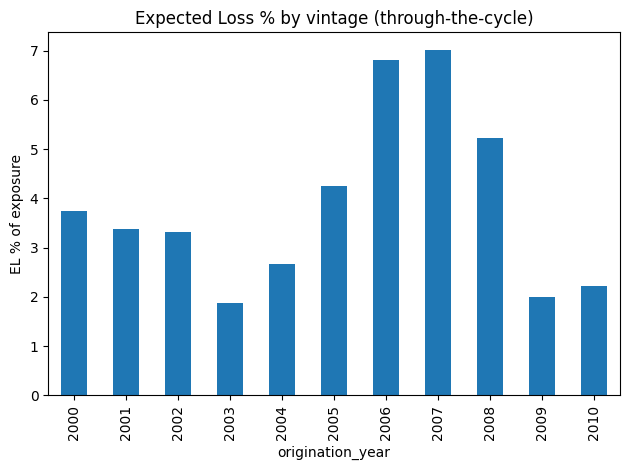

In [6]:
by_vint = book.groupby("origination_year").agg(
    loans=("loan_seq_no","count"), exposure=("EAD","sum"),
    EL=("EL","sum"), mean_PD=("PD","mean"), mean_LGD=("LGD","mean")).reset_index()
by_vint["EL_%"] = (by_vint["EL"]/by_vint["exposure"]*100).round(2)
print(by_vint.round(3).to_string(index=False))

ax = by_vint.plot(x="origination_year", y="EL_%", kind="bar", legend=False,
                  title="Expected Loss % by vintage (through-the-cycle)")
ax.set_ylabel("EL % of exposure"); plt.tight_layout(); plt.show()

In [7]:
out = book[["loan_seq_no", "origination_year", "PD", "LGD", "EAD", "EL"]].copy()
out.to_parquet("expected_loss_output.parquet")
print("saved expected_loss_output.parquet:", out.shape)
print(out.head())

saved expected_loss_output.parquet: (471654, 6)
    loan_seq_no  origination_year        PD       LGD     EAD           EL
0  F00Q10000049              2000  0.048464  0.451775   50000  1094.730702
1  F00Q10000095              2000  0.299407  0.637407   49000  9351.359269
2  F00Q10000106              2000  0.052282  0.248637  173000  2248.858485
3  F00Q10000108              2000  0.053802  0.317057  147000  2507.569278
4  F00Q10000184              2000  0.072853  0.507819  253000  9360.079867


In [8]:
# STRESS TESTING
# Scenario: 2007-09 mortgage crisis
# PD stress: calibrated from your own vintage data (not assumed)
# LGD stress: from your LGD model OOT split (crisis - benign mean)
# EAD stress: none (fixed-rate mortgages, no drawdown risk)

# calibrate PD multiplier
benign  = by_vint[by_vint["origination_year"].between(2000, 2004)]["mean_PD"].mean()
crisis  = by_vint[by_vint["origination_year"].between(2006, 2008)]["mean_PD"].mean()
PD_STRESS_MULT = crisis / benign

# LGD uplift: directly from your LGD model OOT results
# benign train mean LGD = 0.451, crisis test mean LGD = 0.514
LGD_STRESS_ADD = 0.514 - 0.451    # = 0.063, empirically sourced

print("    STRESS ASSUMPTIONS (empirically calibrated)")
print(f"Benign vintage mean PD  (2000-04): {benign:.4f}")
print(f"Crisis vintage mean PD  (2006-08): {crisis:.4f}")
print(f"PD stress multiplier             : {PD_STRESS_MULT:.2f}x")
print(f"LGD stress add         (OOT gap) : +{LGD_STRESS_ADD:.3f}")
print(f"EAD stress                       : none (fixed-rate mortgages)")
print(f"\nSource: PD multiplier from your own vintage breakdown.")
print(f"        LGD uplift from two-stage model OOT train/test split.")

    STRESS ASSUMPTIONS (empirically calibrated)
Benign vintage mean PD  (2000-04): 0.0900
Crisis vintage mean PD  (2006-08): 0.1852
PD stress multiplier             : 2.06x
LGD stress add         (OOT gap) : +0.063
EAD stress                       : none (fixed-rate mortgages)

Source: PD multiplier from your own vintage breakdown.
        LGD uplift from two-stage model OOT train/test split.


STRESS TEST RESULTS: 2006-08 CRISIS SCENARIO

Metric                                      Base       Stress     Change
------------------------------------------------------------------------
Mean PD                                   0.1156       0.2153     +86.3%
Mean LGD                                   0.287        0.350     +0.063
Total EL ($)                        $3,044,368,297 $6,575,879,680    +116.0%
EL as % of exposure                        3.90%        8.42%      +4.52pp

Stress EL by vintage:
 origination_year  base_%  stress_%  uplift_pp
             2000    3.74      8.63       4.89
             2001    3.37      7.84       4.47
             2002    3.32      7.61       4.29
             2003    1.87      4.23       2.36
             2004    2.67      5.85       3.18
             2005    4.26      9.00       4.74
             2006    6.81     14.02       7.21
             2007    7.02     14.36       7.34
             2008    5.23     11.12       5.89
             2009

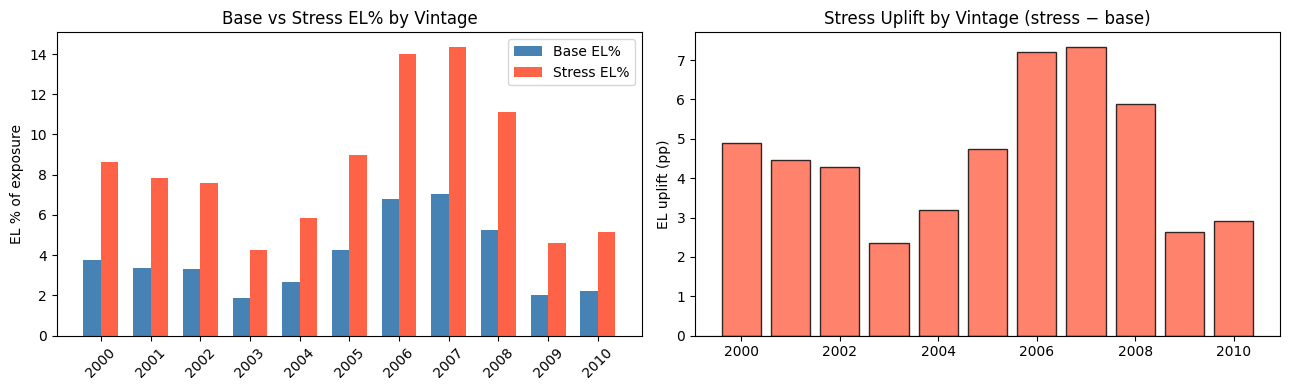


saved stress_el_output.parquet: (471654, 9)


In [9]:
# apply stress and compare 
stress = book.copy()
stress["PD_stress"]  = (stress["PD"]  * PD_STRESS_MULT).clip(0, 1)
stress["LGD_stress"] = (stress["LGD"] + LGD_STRESS_ADD).clip(0, 1)
stress["EL_stress"]  = stress["PD_stress"] * stress["LGD_stress"] * stress["EAD"]

base_el   = book["EL"].sum()
stress_el = stress["EL_stress"].sum()
base_ead  = book["EAD"].sum()

print("=" * 60)
print("STRESS TEST RESULTS: 2006-08 CRISIS SCENARIO")
print("=" * 60)
print(f"\n{'Metric':35s} {'Base':>12s} {'Stress':>12s} {'Change':>10s}")
print("-" * 72)
print(f"{'Mean PD':35s} {book['PD'].mean():>12.4f} "
      f"{stress['PD_stress'].mean():>12.4f} "
      f"{stress['PD_stress'].mean()/book['PD'].mean()-1:>+10.1%}")
print(f"{'Mean LGD':35s} {book['LGD'].mean():>12.3f} "
      f"{stress['LGD_stress'].mean():>12.3f} "
      f"{stress['LGD_stress'].mean()-book['LGD'].mean():>+10.3f}")
print(f"{'Total EL ($)':35s} ${base_el:>11,.0f} ${stress_el:>11,.0f} "
      f"{stress_el/base_el-1:>+10.1%}")
print(f"{'EL as % of exposure':35s} {base_el/base_ead*100:>11.2f}% "
      f"{stress_el/base_ead*100:>11.2f}% "
      f"{stress_el/base_ead*100-base_el/base_ead*100:>+10.2f}pp")

# Vintage breakdown: base vs stress
by_vint_stress = stress.groupby("origination_year").agg(
    EL_base  =("EL","sum"),
    EL_stress=("EL_stress","sum"),
    exposure =("EAD","sum")).reset_index()
by_vint_stress["base_%"]    = (by_vint_stress["EL_base"]   / by_vint_stress["exposure"]*100).round(2)
by_vint_stress["stress_%"]  = (by_vint_stress["EL_stress"] / by_vint_stress["exposure"]*100).round(2)
by_vint_stress["uplift_pp"] = (by_vint_stress["stress_%"]  - by_vint_stress["base_%"]).round(2)
print("\nStress EL by vintage:")
print(by_vint_stress[["origination_year","base_%","stress_%","uplift_pp"]]
      .to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

x = range(len(by_vint_stress))
w = 0.35
axes[0].bar([i-w/2 for i in x], by_vint_stress["base_%"],  w,
            label="Base EL%", color="steelblue")
axes[0].bar([i+w/2 for i in x], by_vint_stress["stress_%"], w,
            label="Stress EL%", color="tomato")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(by_vint_stress["origination_year"], rotation=45)
axes[0].set_ylabel("EL % of exposure")
axes[0].set_title("Base vs Stress EL% by Vintage")
axes[0].legend()

axes[1].bar(by_vint_stress["origination_year"],
            by_vint_stress["uplift_pp"],
            color="tomato", edgecolor="k", alpha=0.8)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("EL uplift (pp)")
axes[1].set_title("Stress Uplift by Vintage (stress − base)")
plt.tight_layout(); plt.show()

stress_out = stress[["loan_seq_no","origination_year",
                      "PD","PD_stress","LGD","LGD_stress",
                      "EAD","EL","EL_stress"]].copy()
stress_out.to_parquet("stress_el_output.parquet")
print("\nsaved stress_el_output.parquet:", stress_out.shape)

VINTAGE EL: ECONOMIC INTERPRETATION

REGIME CLASSIFICATION: LIFETIME DR + MOB EARLY-LIFE ANALYSIS
Regime          Vintages   Lifetime DR  MOB36 DPD   EL%    PD     LGD
----------------------------------------------------------------------
Benign          2000-2004  3.5-7.1%    0.25-1.67%  2.99%   0.090   0.303
Transitional    2005       11.00%      0.62%        4.26%   0.126   0.278
Crisis          2006-2008  9-16%       2.18-6.58%  6.35%   0.185   0.297
Post-crisis     2009-2010  3.2%        0.53-0.62%  2.12%   0.071   0.243

NOTE ON 2004 RECLASSIFICATION:
  Initially classified as transitional based on lifetime DR of 7.1%
  (2x benign average of 3.55%). MOB analysis overturns this.
  MOB36 DPD of 0.34% is LOWER than 2000 (1.67%), 2001 (0.94%),
  2002 (0.49%): 2004 loans performed well in their first 3 years.
  The elevated lifetime DR reflects the 2008-09 crisis hitting
  4-5 year old loans as an exogenous shock, not underwriting failure.
  2004 is BENIGN underwriting, crisis-exposed

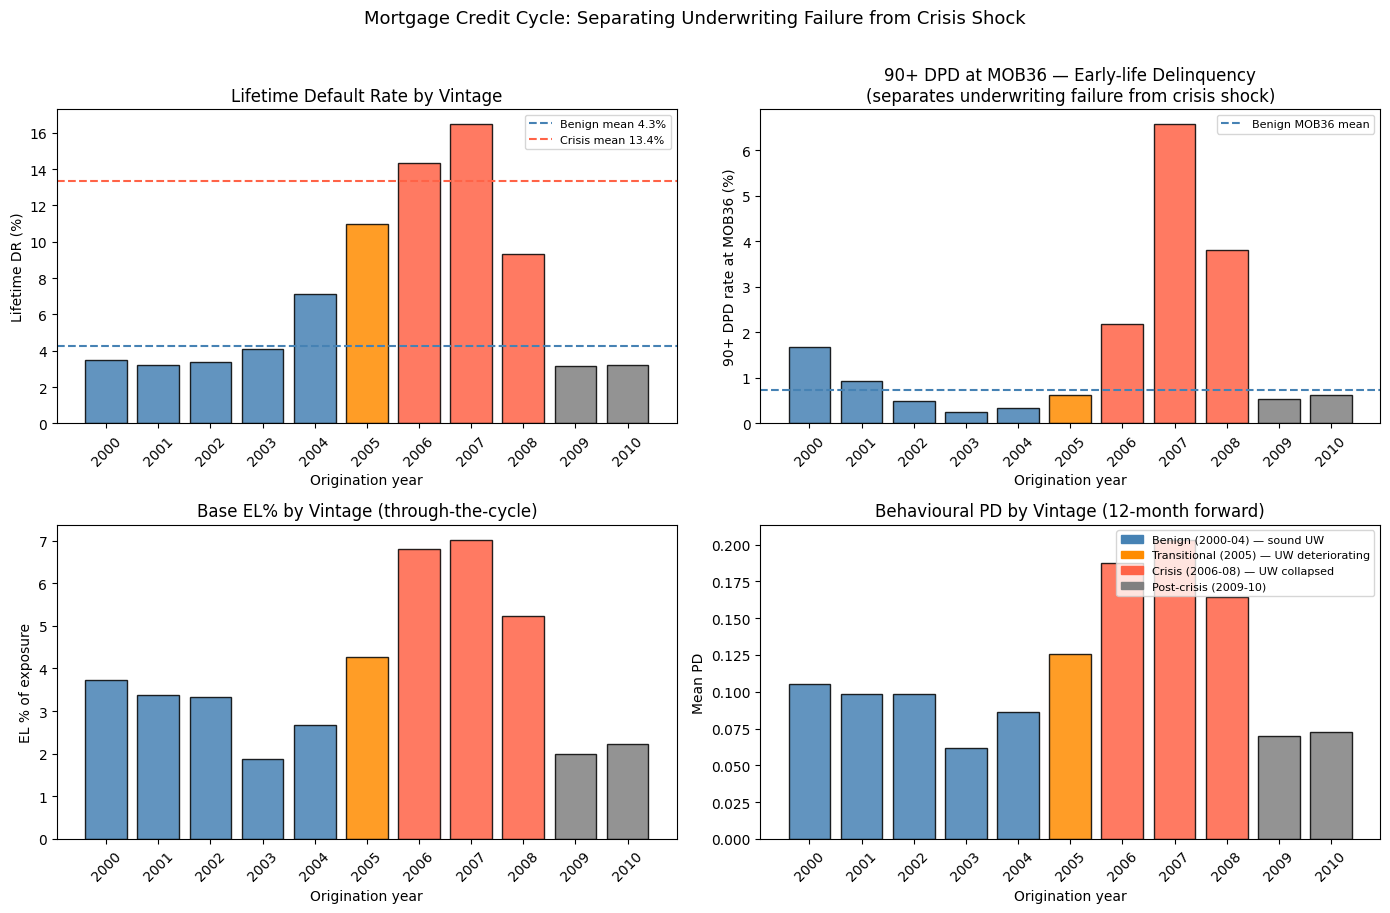

In [ ]:
# ECONOMIC INTERPRETATION
# Why does EL vary across vintages the way it does?

print("=" * 60)
print("VINTAGE EL: ECONOMIC INTERPRETATION")
print("=" * 60)

# Sourced from 02_eda.ipynb, cell "90+ DPD deterioration by months-on-books":
#   lifetime_dr = og_df.groupby("origination_year")["is_default"].mean() * 100
#   mob36       = cohort[36]  (from the MOB pivot table, 90+ DPD by months-on-book)

# actual lifetime default rates
lifetime_dr = {
    2000: 3.49, 2001: 3.23, 2002: 3.40, 2003: 4.07,
    2004: 7.10, 2005: 11.00, 2006: 14.33, 2007: 16.48,
    2008: 9.31, 2009: 3.18, 2010: 3.24
}
ldr = pd.Series(lifetime_dr, name="Lifetime_DR%")

# MOB36 DPD: early-life delinquency (first 3 years only)
mob36 = {
    2000: 1.67, 2001: 0.94, 2002: 0.49, 2003: 0.25,
    2004: 0.34, 2005: 0.62, 2006: 2.18, 2007: 6.58,
    2008: 3.81, 2009: 0.53, 2010: 0.62
}

# regime definitions: grounded in BOTH lifetime DR and MOB data
# 2004 reclassified as benign after MOB analysis
benign_vints = by_vint[by_vint["origination_year"].between(2000, 2004)]
t2005        = by_vint[by_vint["origination_year"] == 2005]
crisis_vints = by_vint[by_vint["origination_year"].between(2006, 2008)]
post_vints   = by_vint[by_vint["origination_year"].between(2009, 2010)]

benign_dr = np.mean([lifetime_dr[y] for y in [2000,2001,2002,2003,2004]])
crisis_dr = np.mean([lifetime_dr[y] for y in [2006,2007,2008]])

print(f"""
REGIME CLASSIFICATION: LIFETIME DR + MOB EARLY-LIFE ANALYSIS
==============================================================
Regime          Vintages   Lifetime DR  MOB36 DPD   EL%    PD     LGD
----------------------------------------------------------------------
Benign          2000-2004  3.5-7.1%    0.25-1.67%  {benign_vints['EL_%'].mean():.2f}%   {benign_vints['mean_PD'].mean():.3f}   {benign_vints['mean_LGD'].mean():.3f}
Transitional    2005       11.00%      0.62%        {t2005['EL_%'].mean():.2f}%   {t2005['mean_PD'].mean():.3f}   {t2005['mean_LGD'].mean():.3f}
Crisis          2006-2008  9-16%       2.18-6.58%  {crisis_vints['EL_%'].mean():.2f}%   {crisis_vints['mean_PD'].mean():.3f}   {crisis_vints['mean_LGD'].mean():.3f}
Post-crisis     2009-2010  3.2%        0.53-0.62%  {post_vints['EL_%'].mean():.2f}%   {post_vints['mean_PD'].mean():.3f}   {post_vints['mean_LGD'].mean():.3f}

NOTE ON 2004 RECLASSIFICATION:
  Initially classified as transitional based on lifetime DR of 7.1%
  (2x benign average of 3.55%). MOB analysis overturns this.
  MOB36 DPD of 0.34% is LOWER than 2000 (1.67%), 2001 (0.94%),
  2002 (0.49%): 2004 loans performed well in their first 3 years.
  The elevated lifetime DR reflects the 2008-09 crisis hitting
  4-5 year old loans as an exogenous shock, not underwriting failure.
  2004 is BENIGN underwriting, crisis-exposed by timing.
""")

pd_ratio  = crisis_vints["mean_PD"].mean()  / benign_vints["mean_PD"].mean()
lgd_ratio = crisis_vints["mean_LGD"].mean() / benign_vints["mean_LGD"].mean()
el_ratio  = crisis_vints["EL_%"].mean()     / benign_vints["EL_%"].mean()

print(f"""
CRISIS vs BENIGN DECOMPOSITION (2006-08 vs 2000-04)
=====================================================
PD ratio  (crisis/benign) : {pd_ratio:.2f}x  = primary driver
LGD ratio (crisis/benign) : {lgd_ratio:.2f}x  = amplifier
EL ratio  (crisis/benign) : {el_ratio:.2f}x  = combined effect
PD x LGD ratio            : {pd_ratio*lgd_ratio:.2f}x  = decomposition check

PD drove the majority of the crisis EL uplift.
LGD amplified it, higher HPI declines at default
increased severity on top of elevated default rates.
""")

# 2x2 chart
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

def bar_color(year):
    if 2000 <= year <= 2004: return "steelblue"   # benign (includes 2004)
    if year == 2005:         return "darkorange"   # transitional
    if 2006 <= year <= 2008: return "tomato"       # crisis
    return "grey"                                   # post-crisis

colors     = [bar_color(y) for y in by_vint["origination_year"]]
ldr_colors = [bar_color(y) for y in ldr.index]
mob_colors = [bar_color(y) for y in mob36.keys()]

# top-left: lifetime DR
axes[0,0].bar(ldr.index, ldr.values, color=ldr_colors, edgecolor="k", alpha=0.85)
axes[0,0].axhline(benign_dr, color="steelblue", ls="--", lw=1.5,
                  label=f"Benign mean {benign_dr:.1f}%")
axes[0,0].axhline(crisis_dr, color="tomato", ls="--", lw=1.5,
                  label=f"Crisis mean {crisis_dr:.1f}%")
axes[0,0].set_title("Lifetime Default Rate by Vintage")
axes[0,0].set_ylabel("Lifetime DR (%)")
axes[0,0].legend(fontsize=8)
axes[0,0].set_xticks(list(ldr.index))

# top-right: MOB36 DPD
axes[0,1].bar(list(mob36.keys()), list(mob36.values()),
              color=mob_colors, edgecolor="k", alpha=0.85)
axes[0,1].axhline(np.mean([mob36[y] for y in [2000,2001,2002,2003,2004]]),
                  color="steelblue", ls="--", lw=1.5,
                  label=f"Benign MOB36 mean")
axes[0,1].set_title("90+ DPD at MOB36 — Early-life Delinquency\n"
                     "(separates underwriting failure from crisis shock)")
axes[0,1].set_ylabel("90+ DPD rate at MOB36 (%)")
axes[0,1].legend(fontsize=8)
axes[0,1].set_xticks(list(mob36.keys()))

# bottom-left: base EL%
axes[1,0].bar(by_vint["origination_year"], by_vint["EL_%"],
              color=colors, edgecolor="k", alpha=0.85)
axes[1,0].set_title("Base EL% by Vintage (through-the-cycle)")
axes[1,0].set_ylabel("EL % of exposure")
axes[1,0].set_xticks(by_vint["origination_year"])

# bottom-right: mean PD
axes[1,1].bar(by_vint["origination_year"], by_vint["mean_PD"],
              color=colors, edgecolor="k", alpha=0.85)
axes[1,1].set_title("Behavioural PD by Vintage (12-month forward)")
axes[1,1].set_ylabel("Mean PD")
axes[1,1].set_xticks(by_vint["origination_year"])

# shared legend
from matplotlib.patches import Patch
legend_els = [
    Patch(color="steelblue",  label="Benign (2000-04) — sound UW"),
    Patch(color="darkorange", label="Transitional (2005) — UW deteriorating"),
    Patch(color="tomato",     label="Crisis (2006-08) — UW collapsed"),
    Patch(color="grey",       label="Post-crisis (2009-10)"),
]
axes[1,1].legend(handles=legend_els, loc="upper right", fontsize=8)

for ax in axes.flat:
    ax.set_xlabel("Origination year")
    for tick in ax.get_xticklabels():
        tick.set_rotation(45)

plt.suptitle("Mortgage Credit Cycle: Separating Underwriting Failure from Crisis Shock",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()